In [2]:
# Merge GT and Pred CSVs, compute Passable and Correct, and save results
import pandas as pd
import numpy as np
import os

# --- Configure file paths (update as needed) ---
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS"
GT_csv = "GT_wajima_overall.csv"  # Ground Truth CSV (File A)
Pred_csv = "Pred_wajima_overall.csv"  # Prediction CSV (File B)
output_csv = "merged_wajima_overall.csv"

GT_csv = os.path.join(base_dir, GT_csv)
Pred_csv =  os.path.join(base_dir, Pred_csv)
output_csv = os.path.join(base_dir, output_csv)

# --- Required columns ---
required_cols = ['filename', 'angle_deg_clockwise', 'width_m', 'original_road_width_m', 'remaining_road_width_m']

# 1) Read CSVs
dfA = pd.read_csv(GT_csv)
dfB = pd.read_csv(Pred_csv)

# 2) Basic validation: ensure required columns exist
missing_GT = [c for c in required_cols if c not in dfA.columns]
missing_Pred = [c for c in required_cols if c not in dfB.columns]
if missing_GT:
    raise KeyError(f"File A is missing required columns: {missing_GT}")
if missing_Pred:
    raise KeyError(f"File B is missing required columns: {missing_Pred}")

# 3) Select and rename columns with prefixes (keep `filename`)
dfA_sel = dfA[required_cols].copy()
dfB_sel = dfB[required_cols].copy()

dfA_sel = dfA_sel.rename(columns={c: f"GT_{c}" for c in dfA_sel.columns if c != 'filename'})
dfB_sel = dfB_sel.rename(columns={c: f"Pred_{c}" for c in dfB_sel.columns if c != 'filename'})

# 4) Full outer join on `filename` to keep all records
df = pd.merge(dfA_sel, dfB_sel, on='filename', how='outer')

# 5) Fill missing GT columns with defaults: angle_deg_clockwise=0, width_m=0, others=NaN
gt_numeric_cols = ['GT_angle_deg_clockwise', 'GT_width_m']
gt_null_cols = ['GT_original_road_width_m', 'GT_remaining_road_width_m']

for col in gt_numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
for col in gt_null_cols:
    if col in df.columns:
        df[col] = df[col].fillna(np.nan)

# 6) Fill missing Pred columns with defaults: angle_deg_clockwise=0, width_m=0, others=NaN
pred_numeric_cols = ['Pred_angle_deg_clockwise', 'Pred_width_m']
pred_null_cols = ['Pred_original_road_width_m', 'Pred_remaining_road_width_m']

for col in pred_numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
for col in pred_null_cols:
    if col in df.columns:
        df[col] = df[col].fillna(np.nan)

# 7) Compute Passable columns (preserve NaN): >4.0 -> True, <=4.0 -> False, NaN -> 2 (unexpected intact roads)
df['GT_Passable'] = np.where(df['GT_remaining_road_width_m'].isna(), 2, df['GT_remaining_road_width_m'] > 4.0)
df['Pred_Passable'] = np.where(df['Pred_remaining_road_width_m'].isna(), 2, df['Pred_remaining_road_width_m'] > 4.0)

# 8) Compute Correct column: True if equal, False otherwise
df['Correct'] = df['GT_Passable'] == df['Pred_Passable']

df["Error_width_m"] = df["Pred_width_m"] - df["GT_width_m"]
df["Error_original_road_width_m"] = df["Pred_original_road_width_m"] - df["GT_original_road_width_m"]
df["Error_remaining_road_width_m"] = df["Pred_remaining_road_width_m"] - df["GT_remaining_road_width_m"]


# 9) Save to CSV (without index) and keep DataFrame variable for later cells
df.to_csv(output_csv, index=False)

print(f"Saved merged results to: {output_csv} (rows: {len(df)})")

# Keep DataFrame variable for reuse in later cells
merged_gt_pred_df = df

# Show a quick preview
merged_gt_pred_df.head()


Saved merged results to: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS\merged_wajima_overall.csv (rows: 59)


,filename,GT_angle_deg_clockwise,GT_width_m,GT_original_road_width_m,GT_remaining_road_width_m,Pred_angle_deg_clockwise,Pred_width_m,Pred_original_road_width_m,Pred_remaining_road_width_m,GT_Passable,Pred_Passable,Correct,Error_width_m,Error_original_road_width_m,Error_remaining_road_width_m
0,b10_HouseCollapse_110_wajima_roadpolygon_linkw...,5.325741,3.542576,11.862516,8.319941,2.624220,1.227862,11.939776,10.711913,1,1,True,-2.314713,0.077260,2.391973
1,b10_HouseCollapse_127_wajima_roadpolygon_linkw...,87.482082,1.617540,4.859502,3.241962,87.482082,1.317980,4.947952,3.629972,0,0,True,-0.299560,0.088450,0.388010
2,b10_HouseCollapse_160_wajima_roadpolygon_linkw...,55.565092,7.246485,5.826882,-1.419603,55.565092,2.502956,5.702368,3.199412,0,0,True,-4.743529,-0.124514,4.619015
3,b10_HouseCollapse_167_wajima_roadpolygon_linkw...,88.745791,0.608778,7.124683,6.515905,0.000000,0.000000,NaN,NaN,1,2,False,-0.608778,NaN,NaN
4,b10_HouseCollapse_167_wajima_roadpolygon_linkw...,0.000000,0.000000,NaN,NaN,173.134559,2.860593,3.593629,0.733036,2,0,False,2.860593,NaN,NaN


In [ ]:
# Merge two CSVs with identical columns and add region source tracking
import pandas as pd

# --- Configure file paths for identical-column CSVs ---
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS"

csv_a_path = r"merged_wajima_overall.csv"
csv_b_path = r"merged_suzu_overall.csv"
output_region_csv = r"merged_noto_overall.csv"

GT_csv = os.path.join(base_dir, csv_a_path)
Pred_csv =  os.path.join(base_dir, csv_b_path)
output_csv = os.path.join(base_dir, output_region_csv)

# 1) Read both CSVs
dfA = pd.read_csv(csv_a_path)
dfB = pd.read_csv(csv_b_path)

# 2) Verify columns are identical
if set(dfA.columns) != set(dfB.columns):
    print("Warning: Columns differ between files")
    print(f"File A columns: {list(dfA.columns)}")
    print(f"File B columns: {list(dfB.columns)}")

# 3) Add region source column before merging
dfA['region'] = 'wajima'
dfB['region'] = 'suzu'

# 4) Concatenate both DataFrames (append B to A)
df_region = pd.concat([dfA, dfB], ignore_index=True)

# 5) Save to CSV
df_region.to_csv(output_region_csv, index=False)

print(f"Merged CSV saved to: {output_region_csv}")
print(f"Total rows: {len(df_region)}")
print(f"  From CSV A: {len(dfA)} rows")
print(f"  From CSV B: {len(dfB)} rows")
print(f"\nRegion column value counts:\n{df_region['region'].value_counts()}")

# Keep DataFrame for reuse in later cells
region_merged_df = df_region
region_merged_df.head()

Merged CSV saved to: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS\merged_noto_overall.csv
Total rows: 152
  From CSV A: 59 rows
  From CSV B: 93 rows

Region column value counts:
region
suzu      93
wajima    59
Name: count, dtype: int64


,filename,GT_angle_deg_clockwise,GT_width_m,GT_original_road_width_m,GT_remaining_road_width_m,Pred_angle_deg_clockwise,Pred_width_m,Pred_original_road_width_m,Pred_remaining_road_width_m,GT_Passable,Pred_Passable,Correct,Error_width_m,Error_original_road_width_m,Error_remaining_road_width_m,region
0,b10_HouseCollapse_110_wajima_roadpolygon_linkw...,5.325741,3.542576,11.862516,8.319941,2.624220,1.227862,11.939776,10.711913,1,1,True,-2.314713,0.077260,2.391973,wajima
1,b10_HouseCollapse_127_wajima_roadpolygon_linkw...,87.482082,1.617540,4.859502,3.241962,87.482082,1.317980,4.947952,3.629972,0,0,True,-0.299560,0.088450,0.388010,wajima
2,b10_HouseCollapse_160_wajima_roadpolygon_linkw...,55.565092,7.246485,5.826882,-1.419603,55.565092,2.502956,5.702368,3.199412,0,0,True,-4.743529,-0.124514,4.619015,wajima
3,b10_HouseCollapse_167_wajima_roadpolygon_linkw...,88.745791,0.608778,7.124683,6.515905,0.000000,0.000000,NaN,NaN,1,2,False,-0.608778,NaN,NaN,wajima
4,b10_HouseCollapse_167_wajima_roadpolygon_linkw...,0.000000,0.000000,NaN,NaN,173.134559,2.860593,3.593629,0.733036,2,0,False,2.860593,NaN,NaN,wajima


Loaded CSV: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS\merged_noto_overall.csv
Total rows: 152

Valid rows (no NaN): 152
Skipped rows (NaN): 0

Confusion Matrix:
[[48  4 29]
 [ 9 17 12]
 [19 14  0]]

IoU per class:
  Class 0 (Not Passable): 0.4404
  Class 1 (Passable): 0.3036
  Class 2 (Intact (unexpected)): 0.0000
mIoU (mean IoU): 0.3720

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.59      0.61        81
           1       0.49      0.45      0.47        38
           2       0.00      0.00      0.00        33

    accuracy                           0.43       152
   macro avg       0.37      0.35      0.36       152
weighted avg       0.46      0.43      0.44       152


Accuracy: 0.4276
Precision (macro): 0.3724
Recall (macro): 0.3467
F1-Score (macro): 0.3591

Error_width_m Statistics:
  Sample Mean: 0.035531
  Sample Variance: 8.030847
  Sample Std Dev: 2.833875
  Population Mean: 0.035531
  Unbias

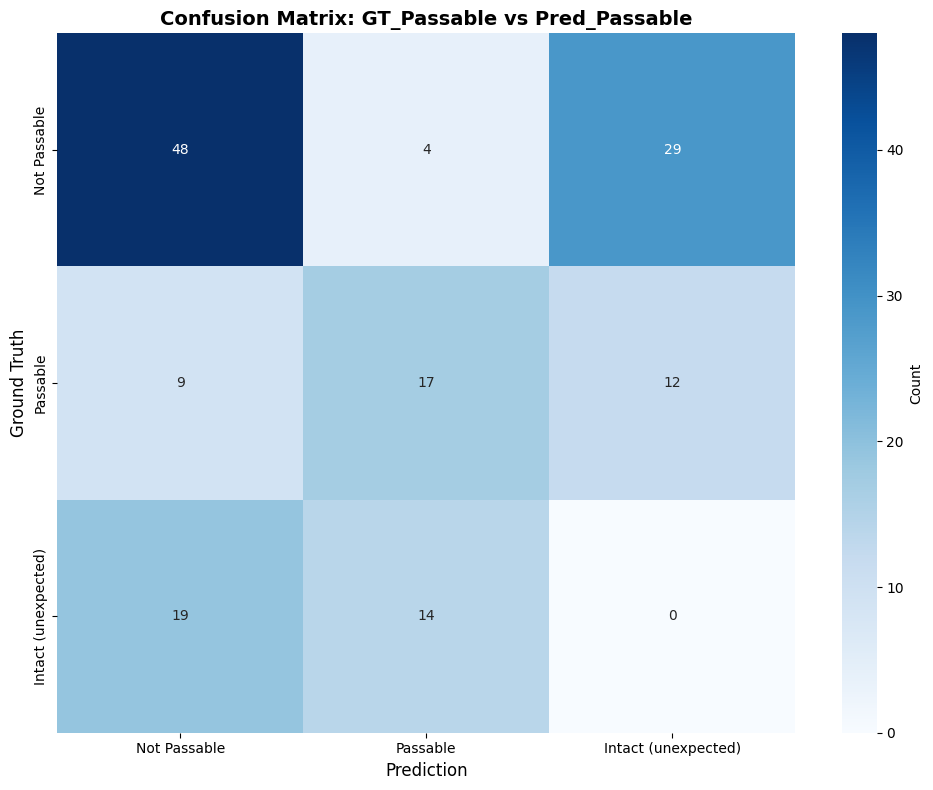

Box Plot PNG saved to: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS\error_width_boxplot.png


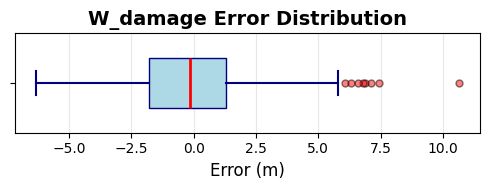


Evaluation completed successfully!

SUMMARY OF RESULTS
                           Metric      Value
                       Total Rows 152.000000
              Valid Rows (no NaN) 152.000000
                         Accuracy   0.427632
                Precision (macro)   0.372431
                   Recall (macro)   0.346654
                 F1-Score (macro)   0.359073
     IoU - Class 0 (Not Passable)   0.440367
         IoU - Class 1 (Passable)   0.303571
           IoU - Class 2 (Intact)   0.000000
                             mIoU   0.371969
      Error_width_m - Sample Mean   0.035531
  Error_width_m - Sample Variance   8.030847
   Error_width_m - Sample Std Dev   2.833875
  Error_width_m - Population Mean   0.035531
Error_width_m - Unbiased Variance   8.084031
 Error_width_m - Unbiased Std Dev   2.843243
     Error_width_m - 95% CI Lower  -0.420123
     Error_width_m - 95% CI Upper   0.491185
      Error_width_m - Valid Count 152.000000


In [22]:
# Evaluate merged_noto_overall.csv using Confusion Matrix, IoU, and Error Statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# --- Load the merged CSV ---
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS"
csv_path = os.path.join(base_dir, "merged_noto_overall.csv")
metrics_output_csv = os.path.join(base_dir, "evaluation_metrics.csv")
cm_output_png = os.path.join(base_dir, "confusion_matrix.png")
boxplot_output_png = os.path.join(base_dir, "error_width_boxplot.png")

df = pd.read_csv(csv_path)

print(f"Loaded CSV: {csv_path}")
print(f"Total rows: {len(df)}\n")

# --- Extract GT and Pred Passable columns ---
y_true = df['GT_Passable'].values
y_pred = df['Pred_Passable'].values

# --- Handle NaN values (if any) ---
valid_mask = ~(np.isnan(y_true) | np.isnan(y_pred))
y_true_clean = y_true[valid_mask].astype(int)
y_pred_clean = y_pred[valid_mask].astype(int)

print(f"Valid rows (no NaN): {len(y_true_clean)}")
print(f"Skipped rows (NaN): {len(y_true) - len(y_true_clean)}\n")

# --- Compute Confusion Matrix ---
cm = confusion_matrix(y_true_clean, y_pred_clean, labels=[0, 1, 2])
print("Confusion Matrix:")
print(cm)
print()

# --- Calculate IoU for each class ---
def calculate_iou_per_class(cm):
    """Calculate IoU for each class from confusion matrix"""
    iou_scores = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        iou_scores.append(iou)
    return iou_scores

iou_per_class = calculate_iou_per_class(cm)
iou_per_class_noclass2 = iou_per_class[:2]  # Exclude class 2 IoU since it's 0
miou = np.mean(iou_per_class_noclass2)

print("IoU per class:")
for i, iou in enumerate(iou_per_class):
    class_name = ['Not Passable', 'Passable', 'Intact (unexpected)'][i]
    print(f"  Class {i} ({class_name}): {iou:.4f}")
print(f"mIoU (mean IoU): {miou:.4f}")
print()

# --- Classification Report ---
print("Classification Report:")
print(classification_report(y_true_clean, y_pred_clean, labels=[0, 1, 2]))
print()

# --- Overall Metrics ---
accuracy = accuracy_score(y_true_clean, y_pred_clean)
print(f"Accuracy: {accuracy:.4f}")

try:
    precision_macro = precision_score(y_true_clean, y_pred_clean, average='macro', zero_division=0)
    recall_macro = recall_score(y_true_clean, y_pred_clean, average='macro', zero_division=0)
    f1_macro = f1_score(y_true_clean, y_pred_clean, average='macro', zero_division=0)
    
    print(f"Precision (macro): {precision_macro:.4f}")
    print(f"Recall (macro): {recall_macro:.4f}")
    print(f"F1-Score (macro): {f1_macro:.4f}")
except Exception as e:
    print(f"Error computing metrics: {e}")

print()

# --- Calculate statistics for Error_width_m ---
error_width = df["Error_width_m"].dropna().values

mean_val = np.mean(error_width)
sample_var = np.var(error_width, ddof=0)  # ddof=0 for sample variance
sample_std = np.std(error_width, ddof=0)  # ddof=0 for sample standard deviation
population_mean = np.mean(error_width)
unbiased_var = np.var(error_width, ddof=1)  # unbiased variance
unbiased_std = np.std(error_width, ddof=1)  # unbiased standard deviation

# --- Calculate 95% Confidence Interval for population mean ---
confidence_level = 0.95
alpha = 1 - confidence_level
n = len(error_width)
t_value = stats.t.ppf(1 - alpha/2, n - 1)
margin_of_error = t_value * (unbiased_std / np.sqrt(n))
ci_lower = mean_val - margin_of_error
ci_upper = mean_val + margin_of_error

print("Error_width_m Statistics:")
print(f"  Sample Mean: {mean_val:.6f}")
print(f"  Sample Variance: {sample_var:.6f}")
print(f"  Sample Std Dev: {sample_std:.6f}")
print(f"  Population Mean: {population_mean:.6f}")
print(f"  Unbiased Variance: {unbiased_var:.6f}")
print(f"  95% CI for Population Mean: [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"  Number of valid Error_width_m values: {len(error_width)}")
print()

# --- Prepare metrics DataFrame ---
metrics_data = {
    'Metric': [
        'Total Rows',
        'Valid Rows (no NaN)',
        'Accuracy',
        'Precision (macro)',
        'Recall (macro)',
        'F1-Score (macro)',
        'IoU - Class 0 (Not Passable)',
        'IoU - Class 1 (Passable)',
        'IoU - Class 2 (Intact)',
        'mIoU',
        'Error_width_m - Sample Mean',
        'Error_width_m - Sample Variance',
        'Error_width_m - Sample Std Dev',
        'Error_width_m - Population Mean',
        'Error_width_m - Unbiased Variance',
        'Error_width_m - Unbiased Std Dev',
        'Error_width_m - 95% CI Lower',
        'Error_width_m - 95% CI Upper',
        'Error_width_m - Valid Count'
    ],
    'Value': [
        len(df),
        len(y_true_clean),
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        iou_per_class[0],
        iou_per_class[1],
        iou_per_class[2],
        miou,
        mean_val,
        sample_var,
        sample_std,
        population_mean,
        unbiased_var,
        unbiased_std,
        ci_lower,
        ci_upper,
        len(error_width)
    ]
}

metrics_df = pd.DataFrame(metrics_data)

# --- Save Confusion Matrix as text in CSV ---
cm_output_text_csv = os.path.join(base_dir, "confusion_matrix.csv")
cm_df = pd.DataFrame(cm, 
                     columns=['Pred: Not Passable', 'Pred: Passable', 'Pred: Intact'],
                     index=['GT: Not Passable', 'GT: Passable', 'GT: Intact'])
cm_df.to_csv(cm_output_text_csv)

# --- Save all metrics to CSV ---
metrics_df.to_csv(metrics_output_csv, index=False)
print(f"Metrics saved to: {metrics_output_csv}")
print(f"Confusion Matrix saved to: {cm_output_text_csv}")
print()

# --- Visualize Confusion Matrix and save as PNG ---
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Passable', 'Passable', 'Intact (unexpected)'],
            yticklabels=['Not Passable', 'Passable', 'Intact (unexpected)'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix: GT_Passable vs Pred_Passable', fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=12)
plt.xlabel('Prediction', fontsize=12)
plt.tight_layout()
plt.savefig(cm_output_png, dpi=300, bbox_inches='tight')
print(f"Confusion Matrix PNG saved to: {cm_output_png}")
plt.show()

# --- Create and save Box Plot for Error_width_m ---
plt.figure(figsize=(5, 2))
box_plot = plt.boxplot(error_width, vert=False, patch_artist=True, widths=0.5)
box_plot['boxes'][0].set_facecolor('lightblue')
box_plot['boxes'][0].set_edgecolor('navy')
for whisker in box_plot['whiskers']:
    whisker.set(color='navy', linewidth=1.5)
for cap in box_plot['caps']:
    cap.set(color='navy', linewidth=1.5)
box_plot['medians'][0].set(color='red', linewidth=2)
for flier in box_plot['fliers']:
    flier.set(marker='o', markerfacecolor='red', markersize=5, alpha=0.5)

plt.xlabel('Error (m)', fontsize=12)
plt.title('W_damage Error Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.yticks([1], [''])

# # Add statistics text
# textstr = f'Mean: {mean_val:.4f}\nMedian: {np.median(error_width):.4f}\nStd Dev: {unbiased_std:.4f}\nMin: {np.min(error_width):.4f}\nMax: {np.max(error_width):.4f}'
# plt.text(1.3, np.min(error_width), textstr, fontsize=10, verticalalignment='top',
#          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(boxplot_output_png, dpi=300, bbox_inches='tight')
print(f"Box Plot PNG saved to: {boxplot_output_png}")
plt.show()

print("\nEvaluation completed successfully!")
print("\n" + "="*60)
print("SUMMARY OF RESULTS")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

In [8]:
# Cell 4: Merge CSVs with partial filename matching
import pandas as pd
import os

# --- Configure file paths ---
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS"

csv_a_path = os.path.join(base_dir, "merged_noto_overall.csv")  # Update with actual filename
csv_b_path = os.path.join(base_dir, "Bestmodel_epoch070_per_image_metrics_20260107_1428_attributed_v1.0.csv")  # Update with actual filename
output_csv = os.path.join(base_dir, "merged_QGIS_Seg.csv")

# 1) Read both CSVs
dfA = pd.read_csv(csv_a_path)
dfB = pd.read_csv(csv_b_path)

print(f"CSV A rows: {len(dfA)}, CSV B rows: {len(dfB)}")

# 2) Automatically extract all attributes from CSV B except 'image'
attributes_b = [col for col in dfB.columns if col != 'image']
print(f"Attributes to extract from CSV B: {attributes_b}")

# 3) Create a copy of dfA (keep all columns and rows)
df_result = dfA.copy()

# 4) Initialize new columns for attributes from B
for attr in attributes_b:
    df_result[attr] = None

# 5) Partial match: for each row in A, check if filename contains any B filename
for idx_a, row_a in dfA.iterrows():
    filename_a = str(row_a['filename'])
    
    # Search for matching filename in B (partial match)
    for idx_b, row_b in dfB.iterrows():
        filename_b = str(row_b['image']).split(".")[0]  # Extract base name without extension
        
        # Check if B's filename is contained in A's filename
        if filename_b in filename_a:
            # Copy attributes from B to result
            for attr in attributes_b:
                if attr in dfB.columns:
                    df_result.at[idx_a, attr] = row_b[attr]
            break  # Found match, move to next A row

# 6) Save to CSV
df_result.to_csv(output_csv, index=False)

print(f"\nMerge completed!")
print(f"Output CSV: {output_csv}")
print(f"Total rows: {len(df_result)}")
print(f"Columns added: {attributes_b}")
print(f"\nPreview:")
print(df_result.head())

CSV A rows: 152, CSV B rows: 100
Attributes to extract from CSV B: ['loss', 'mIoU', 'pixel_acc', 'mean_acc', 'iou_class0', 'iou_class1', 'precision_class0', 'precision_class1', 'recall_class0', 'recall_class1', 'f1_class0', 'f1_class1', 'TP', 'FP', 'TN', 'FN', 'Total', 'Roof_Covered', 'Not_Centered', 'Intact_House', 'Cropped_Off', 'Shady', 'Dark', 'Cloudy', 'Tree', 'Snow', 'Objects', 'Seam', 'Other', 'Classification_CLASS', 'Classification_TrueLabel', 'Classification_PredictedLabel', 'Classification_Correct']

Merge completed!
Output CSV: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS\merged_QGIS_Seg.csv
Total rows: 152
Columns added: ['loss', 'mIoU', 'pixel_acc', 'mean_acc', 'iou_class0', 'iou_class1', 'precision_class0', 'precision_class1', 'recall_class0', 'recall_class1', 'f1_class0', 'f1_class1', 'TP', 'FP', 'TN', 'FN', 'Total', 'Roof_Covered', 'Not_Centered', 'Intact_House', 'Cropped_Off', 'Shady', 'Dark', 'Cloudy', 'Tree', 'Snow', 'Objects', 'Seam', 'Other', 'Cla

In [6]:
# カイ二乗検定（AI判定 True/False と属性 0/1 の関連）
# ついている属性全てに対して，AIの判定結果True/Falseとの関係を調べる
# さらに、正解ラベル（例: Damaged / Intact）ごとに分けて検定を行う
# 使い方:
# 1) 下の csv_path, label_col に加えて truth_col とそのカテゴリ値を編集してください
# 2) 実行すると、各属性ごとの分割表、カイ二乗統計量、p値、効果量(Cramer's V)、多重比較補正結果を、正解ラベルごとに表示します

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from pathlib import Path

# ===== ユーザーが設定するパラメータ =====

# ファイルAとBを読み込む
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS"

csv_path = os.path.join(base_dir, "merged_attr_match.csv")


# AIの判定結果(True/False: 正解/不正解)の列名
label_col = "Correct"  # 例: "Correct" など T/F を格納する列

# 正解ラベル（GT）の列名と、Damaged/Intact に相当する値
truth_col = "GT_Passable"  # 例: "TrueLabel" や "GT"
truth_value_unpassable = 0  # 正解ラベルが Damaged を表す値
truth_value_passable = 1    # 正解ラベルが Intact を表す値
truth_value_absent = 2    # 正解ラベルが Intact を表す値（存在しない場合）

# 調べたい属性列（0/1のカテゴリカル想定）
attribute_cols = [
    "Roof_Covered",
    "Not_Centered",
    "Intact_House",
    "Cropped_Off",
    "Shady",
    "Dark",
    "Cloudy",
    "Tree",
    "Snow",
    "Objects",
    "Seam",
]
# =====================================

# 0/1, True/False, '0'/'1', 'True'/'False' を 0/1 に統一
def to_binary_series(s: pd.Series) -> pd.Series:
    mapping = {
        True: 1, False: 0,
        "True": 1, "False": 0,
        "TRUE": 1, "FALSE": 0,
        "true": 1, "false": 0,
        1: 1, 0: 0,
        "1": 1, "0": 0,
    }
    return s.map(mapping).astype("Int64")

# Benjamini-Hochberg (FDR) の簡易実装
# 戻り値: boolean配列(有意かどうか), 補正後p値
def benjamini_hochberg(pvals, alpha=0.05):
    pvals = np.asarray(pvals, dtype=float)
    n = pvals.size
    order = np.argsort(pvals)
    ranked_p = pvals[order]
    bh_crit = (np.arange(1, n + 1) / n) * alpha
    # 最大の i で p(i) <= (i/m)*alpha を満たす点まで有意
    is_sig_sorted = ranked_p <= bh_crit
    if is_sig_sorted.any():
        max_i = np.where(is_sig_sorted)[0].max()
        is_sig_sorted[: max_i + 1] = True
        is_sig_sorted[max_i + 1 :] = False
    # 補正後p値（q値）
    qvals = ranked_p * n / (np.arange(1, n + 1))
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    # 元の順序に戻す
    is_sig = np.empty_like(is_sig_sorted)
    is_sig[order] = is_sig_sorted
    qvals_out = np.empty_like(qvals)
    qvals_out[order] = qvals
    return is_sig, qvals_out

# Cramer's V（2x2ならPhi係数と同等）
def cramers_v_from_table(table: np.ndarray) -> float:
    chi2, _, _, _ = chi2_contingency(table, correction=True)
    n = table.sum()
    r, k = table.shape
    phi2 = chi2 / n
    # r,k の小さい方-1 を使う（2x2で1）
    return float(np.sqrt(phi2 / max(min(r - 1, k - 1), 1)))

# 入力チェック
csv_path = Path(csv_path)
if not csv_path.exists():
    raise FileNotFoundError(f"CSVが見つかりません: {csv_path}")

# 読み込み
df = pd.read_csv(csv_path)

if label_col not in df.columns:
    raise KeyError(f"label_col '{label_col}' がCSVに見つかりません。列名を確認してください。")

# ラベルと属性を0/1に統一
label = to_binary_series(df[label_col])

available_attrs = [c for c in attribute_cols if c in df.columns]
missing_attrs = [c for c in attribute_cols if c not in df.columns]
if missing_attrs:
    print(f"警告: 次の属性列が見つかりませんでした -> {missing_attrs}")

attr_data = {c: to_binary_series(df[c]) for c in available_attrs}

# グループ定義（正解ラベルごと）。truth_col が無ければ全体のみ
groups = []
if truth_col in df.columns:
    groups = [
        (f"{truth_col}={truth_value_unpassable}", df[truth_col] == truth_value_unpassable),
        (f"{truth_col}={truth_value_passable}", df[truth_col] == truth_value_passable),
        (f"{truth_col}={truth_value_absent}", df[truth_col] == truth_value_absent),
    ]
else:
    print(f"警告: truth_col '{truth_col}' が見つかりません。全体（未分割）で実行します。")
    groups = [("All", pd.Series([True] * len(df), index=df.index))]

aggregated_results = []

for group_name, group_mask in groups:
    print(f"\n==============================")
    print(f"=== カイ二乗検定 結果 (Yates補正あり, 2x2分割) | グループ: {group_name} ===")

    test_results = []  # このグループの各属性の結果

    for c in available_attrs:
        x = attr_data[c]
        valid = group_mask & label.notna() & x.notna()
        if valid.sum() == 0:
            print(f"\n[{c}] 有効データなしのためスキップ (グループ={group_name})")
            test_results.append({
                "group": group_name,
                "attr": c,
                "chi2": np.nan,
                "p": np.nan,
                "cramers_v": np.nan,
                "n": 0,
            })
            continue

        label_v = label[valid].astype(int)
        x_v = x[valid].astype(int)

        # 分割表（行: label 0/1, 列: attr 0/1）
        table = pd.crosstab(label_v, x_v).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        table_np = table.values

        # 期待度数が0になりうる形（行/列の合計が0）は検定不可
        if (
            table_np.sum() == 0
            or (table_np < 0).any()
            or (table_np.sum(axis=0) == 0).any()
            or (table_np.sum(axis=1) == 0).any()
        ):
            print(f"\n[{c}] 行または列和が0のためカイ二乗検定をスキップ (グループ={group_name})")
            test_results.append({
                "group": group_name,
                "attr": c,
                "chi2": np.nan,
                "p": np.nan,
                "cramers_v": np.nan,
                "n": int(valid.sum()),
            })
            continue

        try:
            chi2, p, dof, expected = chi2_contingency(table_np, correction=True)
            v = cramers_v_from_table(table_np)
        except ValueError as e:
            print(f"\n[{c}] 期待度数に0が含まれるためスキップ (グループ={group_name}) | {e}")
            test_results.append({
                "group": group_name,
                "attr": c,
                "chi2": np.nan,
                "p": np.nan,
                "cramers_v": np.nan,
                "n": int(valid.sum()),
            })
            continue

        print(f"\n[{c}] グループ={group_name}")
        print("分割表 (行=AI正誤 0/1, 列=属性 0/1):")
        print(table)
        print(f"n={valid.sum()}, chi2={chi2:.4f}, dof={dof}, p={p:.6g}, Cramer's V={v:.4f}")

        test_results.append({
            "group": group_name,
            "attr": c,
            "chi2": float(chi2),
            "p": float(p),
            "cramers_v": float(v),
            "n": int(valid.sum()),
        })

    # 多重比較補正（グループ内で実施: Bonferroni と BH-FDR）
    results_df = pd.DataFrame(test_results)
    if not results_df.empty:
        pvals = results_df["p"].to_numpy()

        # Bonferroni
        m = np.isfinite(pvals).sum()
        bonf_p = np.where(np.isfinite(pvals), pvals * max(m, 1), np.nan)

        # BH-FDR
        bh_sig, bh_q = benjamini_hochberg(np.where(np.isfinite(pvals), pvals, 1.0), alpha=0.05)

        results_df["p_bonf"] = bonf_p
        results_df["bh_q"] = bh_q
        results_df["sig_0.05_raw"] = results_df["p"] <= 0.05
        results_df["sig_0.05_bonf"] = results_df["p_bonf"] <= 0.05
        results_df["sig_0.05_bh"] = bh_sig

        display_cols = [
            "group", "attr", "n", "chi2", "cramers_v", "p", "p_bonf", "bh_q",
            "sig_0.05_raw", "sig_0.05_bonf", "sig_0.05_bh",
        ]
        print("\n=== まとめ（多重比較補正を含む）: グループ別 ===")
        try:
            from IPython.display import display
            display(results_df[display_cols].sort_values(["group", "p"]))
        except Exception:
            print(results_df[display_cols].sort_values(["group", "p"]).to_string(index=False))

        # 集約: 保存は最後にまとめて行う
        aggregated_results.append(results_df[display_cols])
    else:
        print(f"グループ {group_name} に有効な結果がありませんでした。")




=== カイ二乗検定 結果 (Yates補正あり, 2x2分割) | グループ: GT_Passable=0 ===

[Roof_Covered] グループ=GT_Passable=0
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Roof_Covered   0   1
Correct             
0             15  18
1             22  26
n=81, chi2=0.0000, dof=1, p=1, Cramer's V=0.0000

[Not_Centered] グループ=GT_Passable=0
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Not_Centered   0   1
Correct             
0             23  10
1             35  13
n=81, chi2=0.0042, dof=1, p=0.948166, Cramer's V=0.0072

[Intact_House] グループ=GT_Passable=0
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Intact_House   0   1
Correct             
0             29   4
1             38  10
n=81, chi2=0.5182, dof=1, p=0.471591, Cramer's V=0.0800

[Cropped_Off] グループ=GT_Passable=0
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Cropped_Off   0  1
Correct           
0            33  0
1            46  2
n=81, chi2=0.2105, dof=1, p=0.646413, Cramer's V=0.0510

[Shady] グループ=GT_Passable=0
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Shady     0   1
Correct        
0        23  10
1        30  18
n=81, chi2=0.1862, dof=1

,group,attr,n,chi2,cramers_v,p,p_bonf,bh_q,sig_0.05_raw,sig_0.05_bonf,sig_0.05_bh
6,GT_Passable=0,Cloudy,81,0.996916,0.110940,0.318058,2.862520,1.0,False,False,False
9,GT_Passable=0,Objects,81,0.781636,0.098234,0.376641,3.389771,1.0,False,False,False
10,GT_Passable=0,Seam,81,0.747869,0.096088,0.387152,3.484365,1.0,False,False,False
2,GT_Passable=0,Intact_House,81,0.518246,0.079988,0.471591,4.244316,1.0,False,False,False
3,GT_Passable=0,Cropped_Off,81,0.210452,0.050972,0.646413,5.817720,1.0,False,False,False
4,GT_Passable=0,Shady,81,0.186153,0.047939,0.666138,5.995239,1.0,False,False,False
5,GT_Passable=0,Dark,81,0.127925,0.039741,0.720593,6.485339,1.0,False,False,False
1,GT_Passable=0,Not_Centered,81,0.004226,0.007223,0.948166,8.533498,1.0,False,False,False
0,GT_Passable=0,Roof_Covered,81,0.000000,0.000000,1.000000,9.000000,1.0,False,False,False
7,GT_Passable=0,Tree,81,NaN,NaN,NaN,NaN,1.0,False,False,False



=== カイ二乗検定 結果 (Yates補正あり, 2x2分割) | グループ: GT_Passable=1 ===

[Roof_Covered] グループ=GT_Passable=1
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Roof_Covered   0  1
Correct            
0             13  8
1              9  8
n=38, chi2=0.0511, dof=1, p=0.821152, Cramer's V=0.0367

[Not_Centered] グループ=GT_Passable=1
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Not_Centered   0  1
Correct            
0             13  8
1             11  6
n=38, chi2=0.0000, dof=1, p=1, Cramer's V=0.0000

[Intact_House] グループ=GT_Passable=1
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Intact_House   0  1
Correct            
0             16  5
1             16  1
n=38, chi2=1.1226, dof=1, p=0.289351, Cramer's V=0.1719

[Cropped_Off] グループ=GT_Passable=1
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Cropped_Off   0  1
Correct           
0            21  0
1            16  1
n=38, chi2=0.0115, dof=1, p=0.914573, Cramer's V=0.0174

[Shady] グループ=GT_Passable=1
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Shady     0  1
Correct       
0        15  6
1        14  3
n=38, chi2=0.1631, dof=1, p=0.686291, Cr

,group,attr,n,chi2,cramers_v,p,p_bonf,bh_q,sig_0.05_raw,sig_0.05_bonf,sig_0.05_bh
2,GT_Passable=1,Intact_House,38,1.122637,0.171881,0.289351,2.604163,1.0,False,False,False
4,GT_Passable=1,Shady,38,0.163130,0.065520,0.686291,6.176616,1.0,False,False,False
9,GT_Passable=1,Objects,38,0.096142,0.050300,0.756510,6.808589,1.0,False,False,False
0,GT_Passable=1,Roof_Covered,38,0.051105,0.036672,0.821152,7.390371,1.0,False,False,False
3,GT_Passable=1,Cropped_Off,38,0.011507,0.017402,0.914573,8.231158,1.0,False,False,False
1,GT_Passable=1,Not_Centered,38,0.000000,0.000000,1.000000,9.000000,1.0,False,False,False
5,GT_Passable=1,Dark,38,0.000000,0.000000,1.000000,9.000000,1.0,False,False,False
6,GT_Passable=1,Cloudy,38,0.000000,0.000000,1.000000,9.000000,1.0,False,False,False
7,GT_Passable=1,Tree,38,0.000000,0.000000,1.000000,9.000000,1.0,False,False,False
8,GT_Passable=1,Snow,38,NaN,NaN,NaN,NaN,1.0,False,False,False



=== カイ二乗検定 結果 (Yates補正あり, 2x2分割) | グループ: GT_Passable=2 ===

[Roof_Covered] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Not_Centered] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Intact_House] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Cropped_Off] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Shady] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Dark] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Cloudy] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Tree] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Snow] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Objects] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

[Seam] 行または列和が0のためカイ二乗検定をスキップ (グループ=GT_Passable=2)

=== まとめ（多重比較補正を含む）: グループ別 ===


,group,attr,n,chi2,cramers_v,p,p_bonf,bh_q,sig_0.05_raw,sig_0.05_bonf,sig_0.05_bh
0,GT_Passable=2,Roof_Covered,33,NaN,NaN,NaN,NaN,1.0,False,False,False
1,GT_Passable=2,Not_Centered,33,NaN,NaN,NaN,NaN,1.0,False,False,False
2,GT_Passable=2,Intact_House,33,NaN,NaN,NaN,NaN,1.0,False,False,False
3,GT_Passable=2,Cropped_Off,33,NaN,NaN,NaN,NaN,1.0,False,False,False
4,GT_Passable=2,Shady,33,NaN,NaN,NaN,NaN,1.0,False,False,False
5,GT_Passable=2,Dark,33,NaN,NaN,NaN,NaN,1.0,False,False,False
6,GT_Passable=2,Cloudy,33,NaN,NaN,NaN,NaN,1.0,False,False,False
7,GT_Passable=2,Tree,33,NaN,NaN,NaN,NaN,1.0,False,False,False
8,GT_Passable=2,Snow,33,NaN,NaN,NaN,NaN,1.0,False,False,False
9,GT_Passable=2,Objects,33,NaN,NaN,NaN,NaN,1.0,False,False,False


In [7]:
# 結果をまとめて保存（CSV または TXT）する用のセル
from pathlib import Path
output_path = os.path.join(base_dir, "attr_chi2_test_results.csv")  # 例: r"C:\\Users\\kyohe\\Aerial_Photo_Classifier\\Results\\chi2_summary.csv"

if len(aggregated_results) > 0:
    final_df = pd.concat(aggregated_results, axis=0, ignore_index=True)
    try:
        out_path = Path(output_path)
        if str(out_path) == "" or str(out_path).strip() == "":
            print("output_path が空です。保存をスキップしました。")
        else:
            out_path.parent.mkdir(parents=True, exist_ok=True)
            if str(out_path).lower().endswith('.csv'):
                final_df.to_csv(out_path, index=False, encoding='utf-8-sig')
                print(f"保存しました: {out_path}")
            elif str(out_path).lower().endswith('.txt'):
                # 表形式をテキストで保存
                with open(out_path, 'w', encoding='utf-8') as f:
                    f.write(final_df.sort_values(["group", "p"]).to_string(index=False))
                print(f"保存しました: {out_path}")
            else:
                # 未指定・未対応拡張子は CSV へ
                csv_path = out_path.with_suffix('.csv')
                final_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
                print(f"拡張子未対応のため CSV で保存しました: {csv_path}")
    except Exception as e:
        print(f"結果の保存に失敗しました: {e}")
else:
    print("保存対象となる結果がありませんでした。")

保存しました: C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS\attr_chi2_test_results.csv


In [10]:
from scipy.stats import pointbiserialr
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
import pandas as pd

# ファイルAとBを読み込む
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS"

csv_path = os.path.join(base_dir, "merged_QGIS_Seg.csv")

df_c = pd.read_csv(csv_path)

# カテゴリカル変数の属性名リスト（11個のカテゴリカル変数）
category_vars = [
    "Correct",
    ]

# 連続変数のリスト
continuous_vars = [
    "mIoU",
    "pixel_acc",
    "mean_acc",
    "iou_class0",
    "iou_class1",
    "precision_class0",
    "precision_class1",
    "recall_class0",
    "recall_class1",
    "f1_class0",
    "f1_class1"
]

# 結果を蓄積するリスト
all_corr_results = []
all_lasso_results = []

# 各目的変数に対して解析を実行
for target_var in continuous_vars:
    print("\n" + "=" * 80)
    print(f"目的変数: {target_var}")
    print("=" * 80)
    
    # df_cから必要な列を抽出
    df_analysis = df_c[[target_var] + category_vars].dropna()
    
    # ステップ1: 点二列相関を計算
    print("\n" + "=" * 60)
    print("ステップ1: 点二列相関の計算")
    print("=" * 60)
    
    correlations = {}
    for var in category_vars:
        corr, pval = pointbiserialr(df_analysis[var], df_analysis[target_var])
        correlations[var] = {'correlation': corr, 'p_value': pval, 'abs_corr': abs(corr)}
        print(f"{var}: 相関係数 = {corr:.4f}, p値 = {pval:.4f}")


目的変数: mIoU

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.2434, p値 = 0.0025

目的変数: pixel_acc

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.0855, p値 = 0.2948

目的変数: mean_acc

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.2380, p値 = 0.0031

目的変数: iou_class0

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.0470, p値 = 0.5653

目的変数: iou_class1

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.2745, p値 = 0.0006

目的変数: precision_class0

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.0014, p値 = 0.9867

目的変数: precision_class1

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.2157, p値 = 0.0076

目的変数: recall_class0

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.0619, p値 = 0.4485

目的変数: recall_class1

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.2292, p値 = 0.0045

目的変数: f1_class0

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.0457, p値 = 0.5761

目的変数: f1_class1

ステップ1: 点二列相関の計算
Correct: 相関係数 = 0.2677, p値 = 0.0009


In [9]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# CSVファイルの読み込み
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS"
csv_path = os.path.join(base_dir, "merged_QGIS_Seg.csv")

df = pd.read_csv(csv_path)

# GT_Passableが2のデータを抜き出す
df_absent_GT = df[df['GT_Passable'] == 2].copy()

# Pred_Passableが2のデータを抜き出す
df_absent_Pred = df[df['Pred_Passable'] == 2].copy()

# それ以外のデータを抜き出す（GT_Passable != 2 かつ Pred_Passable != 2）
df_present = df[(df['GT_Passable'] != 2) & (df['Pred_Passable'] != 2)].copy()

print(f"df_absent_GT: {len(df_absent_GT)}行")
print(f"df_absent_Pred: {len(df_absent_Pred)}行")
print(f"df_present: {len(df_present)}行")

# 結果を格納するリスト
results = []

# 1. df_absent_GTとdf_presentの間でGT_width属性のt検定
print("\n" + "="*60)
print("1. Pred_width: df_absent_GT vs df_present")
print("="*60)

gt_absent_width = df_absent_GT['Pred_width_m'].dropna()
gt_present_width = df_present['Pred_width_m'].dropna()

if len(gt_absent_width) > 0 and len(gt_present_width) > 0:
    # 等分散性の検定（Levene検定）
    levene_stat, levene_p = stats.levene(gt_absent_width, gt_present_width)
    equal_var = levene_p > 0.05
    
    # t検定（等分散を仮定するかどうかで使い分け）
    t_stat, p_value = stats.ttest_ind(gt_absent_width, gt_present_width, equal_var=equal_var)
    
    print(f"df_absent_GT - Pred_width_m: n={len(gt_absent_width)}, mean={gt_absent_width.mean():.4f}, std={gt_absent_width.std():.4f}")
    print(f"df_present - Pred_width_m: n={len(gt_present_width)}, mean={gt_present_width.mean():.4f}, std={gt_present_width.std():.4f}")
    print(f"Levene検定 (等分散性): statistic={levene_stat:.4f}, p={levene_p:.4f}, equal_var={equal_var}")
    print(f"t検定: t={t_stat:.4f}, p={p_value:.4f}")
    
    results.append({
        'Comparison': 'Pred_width: absent_GT vs present',
        'Group1': 'absent_GT',
        'Group2': 'present',
        'Attribute': 'Pred_width_m',
        'Group1_n': len(gt_absent_width),
        'Group1_mean': gt_absent_width.mean(),
        'Group1_std': gt_absent_width.std(),
        'Group2_n': len(gt_present_width),
        'Group2_mean': gt_present_width.mean(),
        'Group2_std': gt_present_width.std(),
        'Levene_statistic': levene_stat,
        'Levene_p': levene_p,
        'Equal_variance': equal_var,
        't_statistic': t_stat,
        'p_value': p_value,
        'Significant': p_value < 0.05
    })
else:
    print("データ不足のため、t検定を実行できませんでした。")
    results.append({
        'Comparison': 'Pred_width: absent_GT vs present',
        'Group1': 'absent_GT',
        'Group2': 'present',
        'Attribute': 'Pred_width_m',
        'Group1_n': len(gt_absent_width),
        'Group1_mean': np.nan,
        'Group1_std': np.nan,
        'Group2_n': len(gt_present_width),
        'Group2_mean': np.nan,
        'Group2_std': np.nan,
        'Levene_statistic': np.nan,
        'Levene_p': np.nan,
        'Equal_variance': np.nan,
        't_statistic': np.nan,
        'p_value': np.nan,
        'Significant': False
    })

# 2. df_absent_Predとdf_presentの間でPred_width属性のt検定
print("\n" + "="*60)
print("2. GT_width: df_absent_Pred vs df_present")
print("="*60)

pred_absent_width = df_absent_Pred['GT_width_m'].dropna()
pred_present_width = df_present['GT_width_m'].dropna()

if len(pred_absent_width) > 0 and len(pred_present_width) > 0:
    # 等分散性の検定（Levene検定）
    levene_stat, levene_p = stats.levene(pred_absent_width, pred_present_width)
    equal_var = levene_p > 0.05
    
    # t検定（等分散を仮定するかどうかで使い分け）
    t_stat, p_value = stats.ttest_ind(pred_absent_width, pred_present_width, equal_var=equal_var)
    
    print(f"df_absent_Pred - GT_width_m: n={len(pred_absent_width)}, mean={pred_absent_width.mean():.4f}, std={pred_absent_width.std():.4f}")
    print(f"df_present - GT_width_m: n={len(pred_present_width)}, mean={pred_present_width.mean():.4f}, std={pred_present_width.std():.4f}")
    print(f"Levene検定 (等分散性): statistic={levene_stat:.4f}, p={levene_p:.4f}, equal_var={equal_var}")
    print(f"t検定: t={t_stat:.4f}, p={p_value:.4f}")
    
    results.append({
        'Comparison': 'GT_width: absent_Pred vs present',
        'Group1': 'absent_Pred',
        'Group2': 'present',
        'Attribute': 'GT_width_m',
        'Group1_n': len(pred_absent_width),
        'Group1_mean': pred_absent_width.mean(),
        'Group1_std': pred_absent_width.std(),
        'Group2_n': len(pred_present_width),
        'Group2_mean': pred_present_width.mean(),
        'Group2_std': pred_present_width.std(),
        'Levene_statistic': levene_stat,
        'Levene_p': levene_p,
        'Equal_variance': equal_var,
        't_statistic': t_stat,
        'p_value': p_value,
        'Significant': p_value < 0.05
    })
else:
    print("データ不足のため、t検定を実行できませんでした。")
    results.append({
        'Comparison': 'GT_width: absent_Pred vs present',
        'Group1': 'absent_Pred',
        'Group2': 'present',
        'Attribute': 'GT_width_m',
        'Group1_n': len(pred_absent_width),
        'Group1_mean': np.nan,
        'Group1_std': np.nan,
        'Group2_n': len(pred_present_width),
        'Group2_mean': np.nan,
        'Group2_std': np.nan,
        'Levene_statistic': np.nan,
        'Levene_p': np.nan,
        'Equal_variance': np.nan,
        't_statistic': np.nan,
        'p_value': np.nan,
        'Significant': False
    })

# 結果をDataFrameに変換してCSVに出力
results_df = pd.DataFrame(results)

output_path = os.path.join(base_dir, "t_test_results_absent_vs_present.csv")
results_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print("\n" + "="*60)
print("結果をCSVに出力しました:")
print(f"{output_path}")
print("="*60)
print(results_df.to_string(index=False))


df_absent_GT: 33行
df_absent_Pred: 41行
df_present: 78行

1. Pred_width: df_absent_GT vs df_present
df_absent_GT - Pred_width_m: n=33, mean=2.8500, std=2.4233
df_present - Pred_width_m: n=78, mean=3.1595, std=2.3897
Levene検定 (等分散性): statistic=0.4277, p=0.5145, equal_var=True
t検定: t=-0.6212, p=0.5357

2. GT_width: df_absent_Pred vs df_present
df_absent_Pred - GT_width_m: n=41, mean=2.1412, std=1.5184
df_present - GT_width_m: n=78, mean=3.1706, std=2.0827
Levene検定 (等分散性): statistic=4.0921, p=0.0454, equal_var=False
t検定: t=-3.0781, p=0.0027

結果をCSVに出力しました:
C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS\t_test_results_absent_vs_present.csv
                      Comparison      Group1  Group2    Attribute  Group1_n  Group1_mean  Group1_std  Group2_n  Group2_mean  Group2_std  Levene_statistic  Levene_p  Equal_variance  t_statistic  p_value  Significant
Pred_width: absent_GT vs present   absent_GT present Pred_width_m        33     2.849976    2.423300        78     3.159545    2

In [ ]:
### 分類モデルの結果と通行可否の関係　＃＃＃


# カイ二乗検定（AI判定 True/False と属性 0/1 の関連）
# ついている属性全てに対して，AIの判定結果True/Falseとの関係を調べる
# さらに、正解ラベル（例: Damaged / Intact）ごとに分けて検定を行う
# 使い方:
# 1) 下の csv_path, label_col に加えて truth_col とそのカテゴリ値を編集してください
# 2) 実行すると、各属性ごとの分割表、カイ二乗統計量、p値、効果量(Cramer's V)、多重比較補正結果を、正解ラベルごとに表示します

import pandas as pd
import numpy as np
import os
from scipy.stats import chi2_contingency
from pathlib import Path

# ===== ユーザーが設定するパラメータ =====

# ファイルAとBを読み込む
base_dir = r"C:\Users\kyohe\Aerial_Photo_Segmenter\20260105Data\Result_QGIS"

csv_path = os.path.join(base_dir, "merged_QGIS_Seg.csv")


# AIの判定結果(True/False: 正解/不正解)の列名
label_col = "Correct"  # 例: "Correct" など T/F を格納する列

# 正解ラベル（GT）の列名と、Damaged/Intact に相当する値
truth_col = "GT_Passable"  # 例: "TrueLabel" や "GT"
truth_value_unpassable = 0  # 正解ラベルが Damaged を表す値
truth_value_passable = 1    # 正解ラベルが Intact を表す値
truth_value_absent = 2    # 正解ラベルが Intact を表す値（存在しない場合）

# 調べたい属性列（0/1のカテゴリカル想定）
attribute_cols = [
    "Classification_Correct"
]
# =====================================

# 0/1, True/False, '0'/'1', 'True'/'False' を 0/1 に統一
def to_binary_series(s: pd.Series) -> pd.Series:
    mapping = {
        True: 1, False: 0,
        "True": 1, "False": 0,
        "TRUE": 1, "FALSE": 0,
        "true": 1, "false": 0,
        1: 1, 0: 0,
        "1": 1, "0": 0,
    }
    return s.map(mapping).astype("Int64")

# Benjamini-Hochberg (FDR) の簡易実装
# 戻り値: boolean配列(有意かどうか), 補正後p値
def benjamini_hochberg(pvals, alpha=0.05):
    pvals = np.asarray(pvals, dtype=float)
    n = pvals.size
    order = np.argsort(pvals)
    ranked_p = pvals[order]
    bh_crit = (np.arange(1, n + 1) / n) * alpha
    # 最大の i で p(i) <= (i/m)*alpha を満たす点まで有意
    is_sig_sorted = ranked_p <= bh_crit
    if is_sig_sorted.any():
        max_i = np.where(is_sig_sorted)[0].max()
        is_sig_sorted[: max_i + 1] = True
        is_sig_sorted[max_i + 1 :] = False
    # 補正後p値（q値）
    qvals = ranked_p * n / (np.arange(1, n + 1))
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    # 元の順序に戻す
    is_sig = np.empty_like(is_sig_sorted)
    is_sig[order] = is_sig_sorted
    qvals_out = np.empty_like(qvals)
    qvals_out[order] = qvals
    return is_sig, qvals_out

# Cramer's V（2x2ならPhi係数と同等）
def cramers_v_from_table(table: np.ndarray) -> float:
    chi2, _, _, _ = chi2_contingency(table, correction=True)
    n = table.sum()
    r, k = table.shape
    phi2 = chi2 / n
    # r,k の小さい方-1 を使う（2x2で1）
    return float(np.sqrt(phi2 / max(min(r - 1, k - 1), 1)))

# 入力チェック
csv_path = Path(csv_path)
if not csv_path.exists():
    raise FileNotFoundError(f"CSVが見つかりません: {csv_path}")

# 読み込み
df = pd.read_csv(csv_path)

if label_col not in df.columns:
    raise KeyError(f"label_col '{label_col}' がCSVに見つかりません。列名を確認してください。")

# ラベルと属性を0/1に統一
label = to_binary_series(df[label_col])

available_attrs = [c for c in attribute_cols if c in df.columns]
missing_attrs = [c for c in attribute_cols if c not in df.columns]
if missing_attrs:
    print(f"警告: 次の属性列が見つかりませんでした -> {missing_attrs}")

attr_data = {c: to_binary_series(df[c]) for c in available_attrs}

# グループ定義（正解ラベルごと）。truth_col が無ければ全体のみ
groups = []
if truth_col in df.columns:
    groups = [
        (f"{truth_col}={truth_value_unpassable}", df[truth_col] == truth_value_unpassable),
        (f"{truth_col}={truth_value_passable}", df[truth_col] == truth_value_passable),
        (f"{truth_col}={truth_value_absent}", df[truth_col] == truth_value_absent),
    ]
else:
    print(f"警告: truth_col '{truth_col}' が見つかりません。全体（未分割）で実行します。")
    groups = [("All", pd.Series([True] * len(df), index=df.index))]

aggregated_results = []

for group_name, group_mask in groups:
    print(f"\n==============================")
    print(f"=== カイ二乗検定 結果 (Yates補正あり, 2x2分割) | グループ: {group_name} ===")

    test_results = []  # このグループの各属性の結果

    for c in available_attrs:
        x = attr_data[c]
        valid = group_mask & label.notna() & x.notna()
        if valid.sum() == 0:
            print(f"\n[{c}] 有効データなしのためスキップ (グループ={group_name})")
            test_results.append({
                "group": group_name,
                "attr": c,
                "chi2": np.nan,
                "p": np.nan,
                "cramers_v": np.nan,
                "n": 0,
            })
            continue

        label_v = label[valid].astype(int)
        x_v = x[valid].astype(int)

        # 分割表（行: label 0/1, 列: attr 0/1）
        table = pd.crosstab(label_v, x_v).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        table_np = table.values

        # 期待度数が0になりうる形（行/列の合計が0）は検定不可
        if (
            table_np.sum() == 0
            or (table_np < 0).any()
            or (table_np.sum(axis=0) == 0).any()
            or (table_np.sum(axis=1) == 0).any()
        ):
            print(f"\n[{c}] 行または列和が0のためカイ二乗検定をスキップ (グループ={group_name})")
            test_results.append({
                "group": group_name,
                "attr": c,
                "chi2": np.nan,
                "p": np.nan,
                "cramers_v": np.nan,
                "n": int(valid.sum()),
            })
            continue

        try:
            chi2, p, dof, expected = chi2_contingency(table_np, correction=True)
            v = cramers_v_from_table(table_np)
        except ValueError as e:
            print(f"\n[{c}] 期待度数に0が含まれるためスキップ (グループ={group_name}) | {e}")
            test_results.append({
                "group": group_name,
                "attr": c,
                "chi2": np.nan,
                "p": np.nan,
                "cramers_v": np.nan,
                "n": int(valid.sum()),
            })
            continue

        print(f"\n[{c}] グループ={group_name}")
        print("分割表 (行=AI正誤 0/1, 列=属性 0/1):")
        print(table)
        print(f"n={valid.sum()}, chi2={chi2:.4f}, dof={dof}, p={p:.6g}, Cramer's V={v:.4f}")

        test_results.append({
            "group": group_name,
            "attr": c,
            "chi2": float(chi2),
            "p": float(p),
            "cramers_v": float(v),
            "n": int(valid.sum()),
        })

    # 多重比較補正（グループ内で実施: Bonferroni と BH-FDR）
    results_df = pd.DataFrame(test_results)
    if not results_df.empty:
        pvals = results_df["p"].to_numpy()

        # Bonferroni
        m = np.isfinite(pvals).sum()
        bonf_p = np.where(np.isfinite(pvals), pvals * max(m, 1), np.nan)

        # BH-FDR
        bh_sig, bh_q = benjamini_hochberg(np.where(np.isfinite(pvals), pvals, 1.0), alpha=0.05)

        results_df["p_bonf"] = bonf_p
        results_df["bh_q"] = bh_q
        results_df["sig_0.05_raw"] = results_df["p"] <= 0.05
        results_df["sig_0.05_bonf"] = results_df["p_bonf"] <= 0.05
        results_df["sig_0.05_bh"] = bh_sig

        display_cols = [
            "group", "attr", "n", "chi2", "cramers_v", "p", "p_bonf", "bh_q",
            "sig_0.05_raw", "sig_0.05_bonf", "sig_0.05_bh",
        ]
        print("\n=== まとめ（多重比較補正を含む）: グループ別 ===")
        try:
            from IPython.display import display
            display(results_df[display_cols].sort_values(["group", "p"]))
        except Exception:
            print(results_df[display_cols].sort_values(["group", "p"]).to_string(index=False))

        # 集約: 保存は最後にまとめて行う
        aggregated_results.append(results_df[display_cols])
    else:
        print(f"グループ {group_name} に有効な結果がありませんでした。")



警告: truth_col '' が見つかりません。全体（未分割）で実行します。

=== カイ二乗検定 結果 (Yates補正あり, 2x2分割) | グループ: All ===

[Classification_Correct] グループ=All
分割表 (行=AI正誤 0/1, 列=属性 0/1):
Classification_Correct   0   1
Correct                       
0                       12  55
1                       14  34
n=115, chi2=1.4328, dof=1, p=0.231304, Cramer's V=0.1116

=== まとめ（多重比較補正を含む）: グループ別 ===


,group,attr,n,chi2,cramers_v,p,p_bonf,bh_q,sig_0.05_raw,sig_0.05_bonf,sig_0.05_bh
0,All,Classification_Correct,115,1.432825,0.111621,0.231304,0.231304,0.231304,False,False,False
